In [24]:
import seaborn as sns
import pandas as pd
import numpy as np

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df=pd.read_csv(r"C:\Users\kisho\Downloads\netflix_titles.csv\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [27]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [28]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [29]:
df = df.dropna(subset=["date_added"])

In [30]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

In [31]:
df["rating"] = df["rating"].fillna("Not Rated")

In [32]:
df["duration"] = df["duration"].fillna("Unknown")

In [33]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [35]:
# which type does netfilx have more movies or tv shows
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [36]:
# percentage of type of content 
df["type"].value_counts(normalize=True) * 100


type
Movie      69.694214
TV Show    30.305786
Name: proportion, dtype: float64

In [37]:
# top 10 countries producing content
df["country"].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [38]:
# which years had the highest number of content releases on Netflix
df.groupby("release_year")["title"].count().sort_values(ascending=False)

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
        ... 
1925       1
1947       1
1959       1
1966       1
1961       1
Name: title, Length: 74, dtype: int64

In [39]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [40]:
# the most common content rating categories on Netflix.
df["rating"].value_counts()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [41]:
# the year when each title was added to Netflix from the date_added column.
df["year_added"] = df["date_added"].dt.year

In [42]:
df["year_added"].head()

0    2021
1    2021
2    2021
3    2021
4    2021
Name: year_added, dtype: int32

In [43]:
# the total number of titles added to Netflix in each year
df.groupby("year_added")["title"].count()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: title, dtype: int64

In [77]:
# top 10 directors with the most titles on the platform
df["director"].value_counts().head(10)

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

In [78]:
# the number of Movies and TV Shows added each year
df.groupby(["year_added", "type"])["title"].count()

year_added  type   
2008        Movie         1
            TV Show       1
2009        Movie         2
2010        Movie         1
2011        Movie        13
2012        Movie         3
2013        Movie         6
            TV Show       5
2014        Movie        19
            TV Show       5
2015        Movie        56
            TV Show      26
2016        Movie       253
            TV Show     176
2017        Movie       839
            TV Show     349
2018        Movie      1237
            TV Show     412
2019        Movie      1424
            TV Show     592
2020        Movie      1284
            TV Show     595
2021        Movie       993
            TV Show     505
Name: title, dtype: int64

In [79]:
# top countries producing TV shows on Netflix
df[df["type"]=="TV Show"]["country"].value_counts().head(10)

country
United States     754
Unknown           390
United Kingdom    212
Japan             168
South Korea       158
India              79
Taiwan             68
Canada             59
France             49
Spain              48
Name: count, dtype: int64

In [63]:
# top 10 countries producing Movies on Netflix
df[df["type"]=="Movie"]["country"].value_counts().head(10)

country
United States     2058
India              893
Unknown            440
United Kingdom     206
Canada             122
Spain               97
Egypt               92
Nigeria             86
Indonesia           77
Japan               76
Name: count, dtype: int64

In [64]:
# top 10 genres in Netflix
df["listed_in"].value_counts().head(15)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Comedies, International Movies                      176
Comedies, International Movies, Romantic Movies     152
Dramas                                              138
Dramas, International Movies, Thrillers             134
Action & Adventure, Dramas, International Movies    132
Name: count, dtype: int64

In [65]:
# most common rating categories among movies available on Netflix
df[df["type"]=="Movie"]["rating"].value_counts()

rating
TV-MA        2062
TV-14        1427
R             797
TV-PG         540
PG-13         490
PG            287
TV-Y7         139
TV-Y          131
TV-G          126
NR             75
G              41
TV-Y7-FV        5
NC-17           3
UR              3
Not Rated       2
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [66]:
# most common rating among TV shows availble on netflix
df[df["type"]=="TV Show"]["rating"].value_counts()

rating
TV-MA        1143
TV-14         730
TV-PG         321
TV-Y7         194
TV-Y          175
TV-G           94
NR              4
R               2
Not Rated       2
TV-Y7-FV        1
Name: count, dtype: int64

In [80]:
# movies with the longest duration available on Netflix
df[df["type"] == "Movie"].sort_values("duration", ascending=False).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,Unknown,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,Unknown,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,Unknown,Movies,The comic puts his trademark hilarious/thought...,2016
6415,s6416,Movie,Candyman,Bernard Rose,"Virginia Madsen, Tony Todd, Xander Berkeley, K...","United States, United Kingdom",2019-10-01,1992,R,99 min,"Cult Movies, Horror Movies",Grad student Helen Lyle unintentionally summon...,2019
3411,s3412,Movie,Up North,Tope Oshin,"Banky Wellington, Rahama Sadau, Kanayo O. Kana...",Nigeria,2019-10-18,2018,TV-14,99 min,"Dramas, International Movies",A pampered heir must complete a year of servic...,2019
5893,s5894,Movie,Winter on Fire: Ukraine's Fight for Freedom,Evgeny Afineevsky,Unknown,"United Kingdom, Ukraine, United States",2015-10-09,2015,TV-MA,99 min,"Documentaries, International Movies","Over 93 days in Ukraine, what started as peace...",2015
7924,s7925,Movie,Salem: His Sister's Father,Mohamed Hamdy,"Mohamed Ragab, Horeya Farghaly, Ayten Amer, Mo...",Egypt,2019-06-22,2014,TV-14,99 min,"Dramas, International Movies",A street vendor's simple life is turned upside...,2019
3431,s3432,Movie,The Bling Lagosians,Bolanle Austen-Peters,"Gbenga Titiloye, Elvina Ibru, Sharon Ooja, Osa...",Nigeria,2019-10-11,2019,TV-14,99 min,"Dramas, International Movies",With a matriarch bent on having a lavish 51st ...,2019
7534,s7535,Movie,My Dog is My Guide,Ismail Farouk,"Sameh Hussain, Hasan Abdulfattah, Sulayman Id,...",Egypt,2019-04-18,2013,TV-14,99 min,"Comedies, International Movies",Relocated to a new post and struggling to adju...,2019
5502,s5503,Movie,In the Shadow of Iris,Jalil Lespert,"Romain Duris, Charlotte Le Bon, Jalil Lespert,...","France, Belgium",2017-05-01,2016,TV-MA,99 min,"Dramas, International Movies, Thrillers",The sudden disappearance of a wealthy banker's...,2017


In [68]:
df[df["type"]=="Movie"]["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Comedies, International Movies                      176
Name: count, dtype: int64

In [69]:
df[df["type"]=="TV Show"]["listed_in"].value_counts().head(10)

listed_in
Kids' TV                                                  219
International TV Shows, TV Dramas                         121
Crime TV Shows, International TV Shows, TV Dramas         110
Kids' TV, TV Comedies                                      98
Reality TV                                                 95
International TV Shows, Romantic TV Shows, TV Comedies     94
International TV Shows, Romantic TV Shows, TV Dramas       90
Anime Series, International TV Shows                       88
Docuseries                                                 84
TV Comedies                                                68
Name: count, dtype: int64

In [70]:
df.groupby(["year_added","type"])["title"].count()

year_added  type   
2008        Movie         1
            TV Show       1
2009        Movie         2
2010        Movie         1
2011        Movie        13
2012        Movie         3
2013        Movie         6
            TV Show       5
2014        Movie        19
            TV Show       5
2015        Movie        56
            TV Show      26
2016        Movie       253
            TV Show     176
2017        Movie       839
            TV Show     349
2018        Movie      1237
            TV Show     412
2019        Movie      1424
            TV Show     592
2020        Movie      1284
            TV Show     595
2021        Movie       993
            TV Show     505
Name: title, dtype: int64

In [71]:
df.groupby("type")["release_year"].mean()

type
Movie      2013.121514
TV Show    2016.625656
Name: release_year, dtype: float64

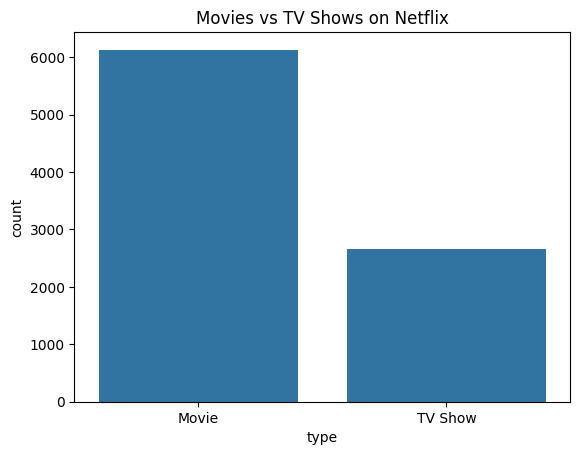

In [47]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

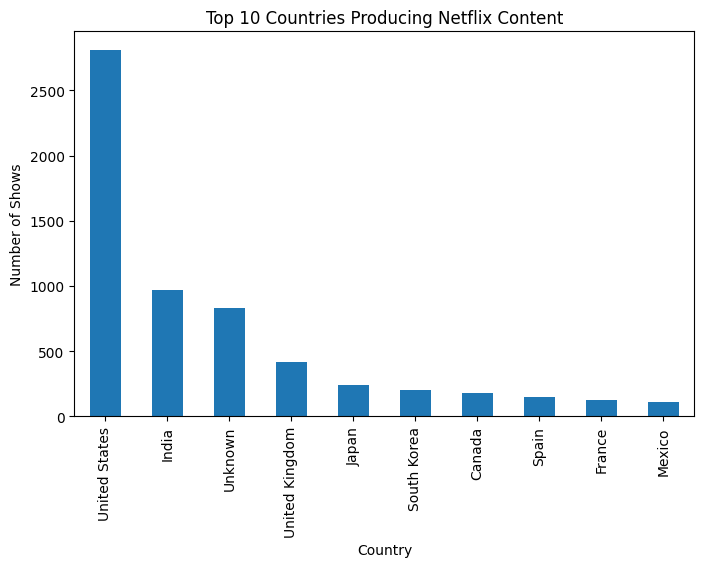

In [48]:
top_countries = df["country"].value_counts().head(10)
top_countries.plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.show()

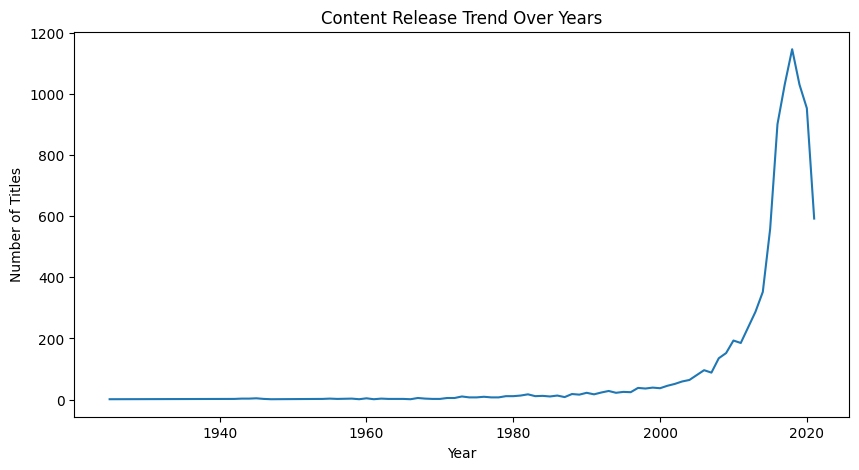

In [49]:
df.groupby("release_year")["title"].count().plot(figsize=(10,5))
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

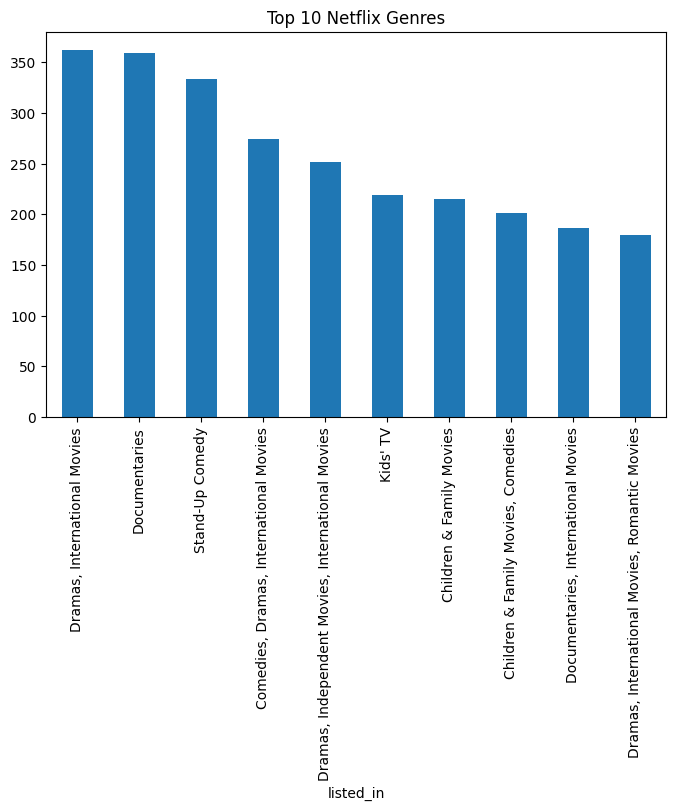

In [50]:
top_genres = df["listed_in"].value_counts().head(10)
top_genres.plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Netflix Genres")
plt.show()

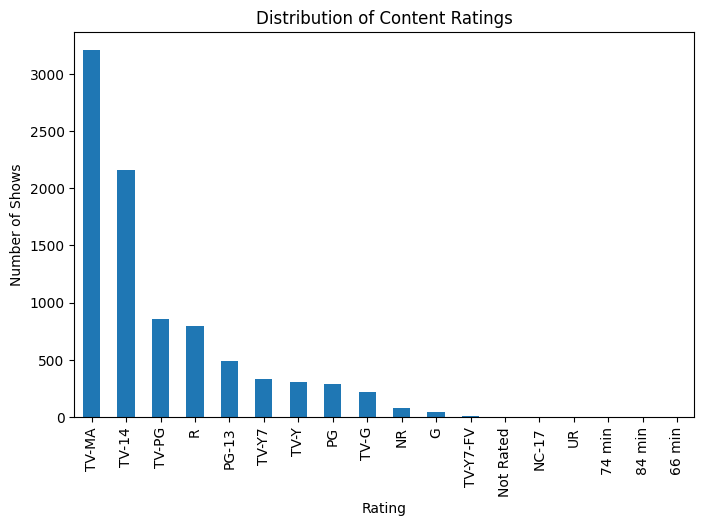

In [51]:
df["rating"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Shows")
plt.show()

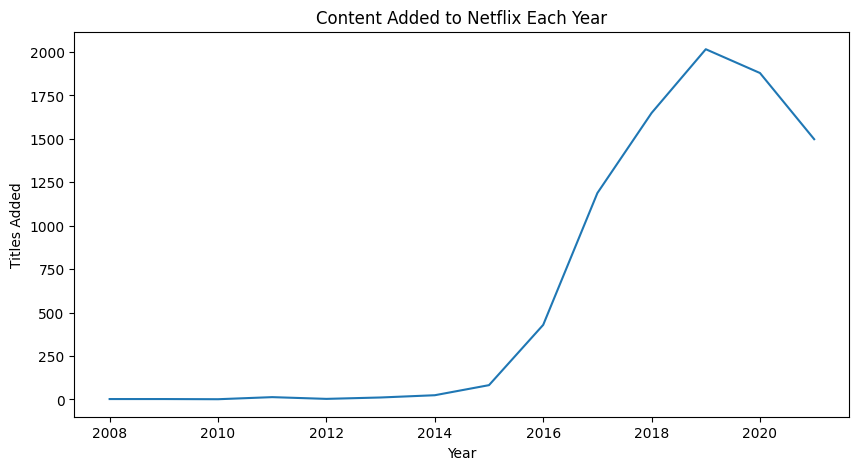

In [52]:
df.groupby("year_added")["title"].count().plot(figsize=(10,5))
plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.show()

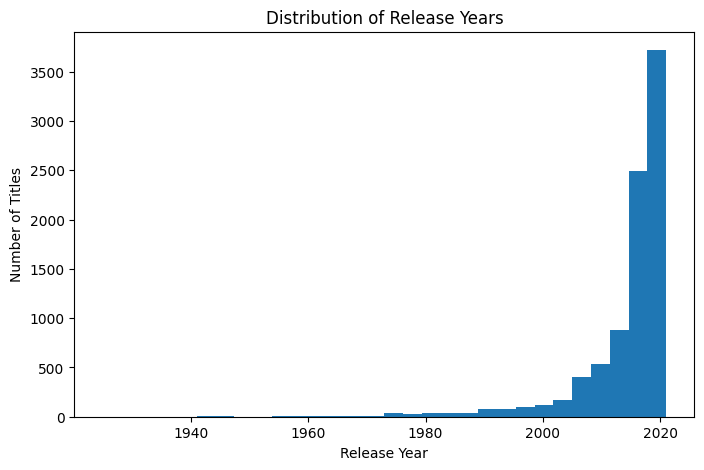

In [53]:
plt.figure(figsize=(8,5))
plt.hist(df["release_year"], bins=30)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

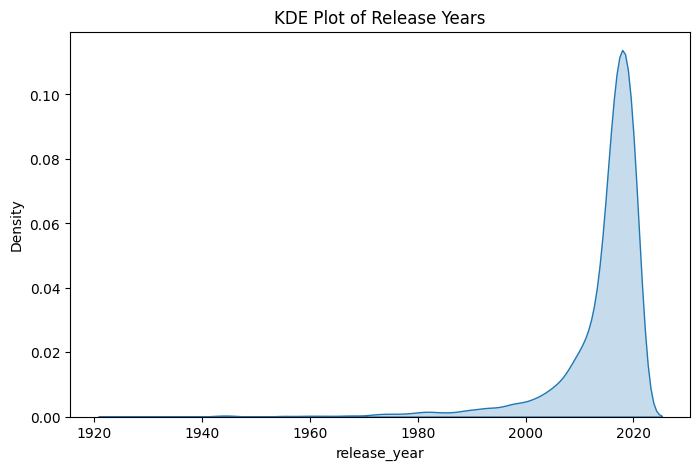

In [54]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["release_year"], fill=True)
plt.title("KDE Plot of Release Years")
plt.show()

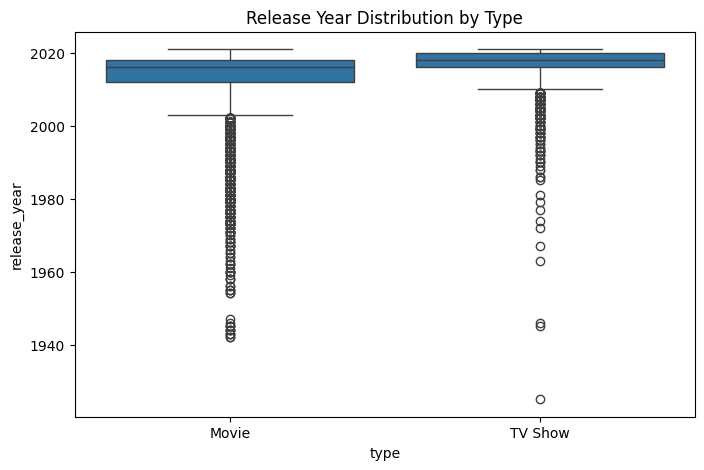

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="type", y="release_year")

plt.title("Release Year Distribution by Type")
plt.show()

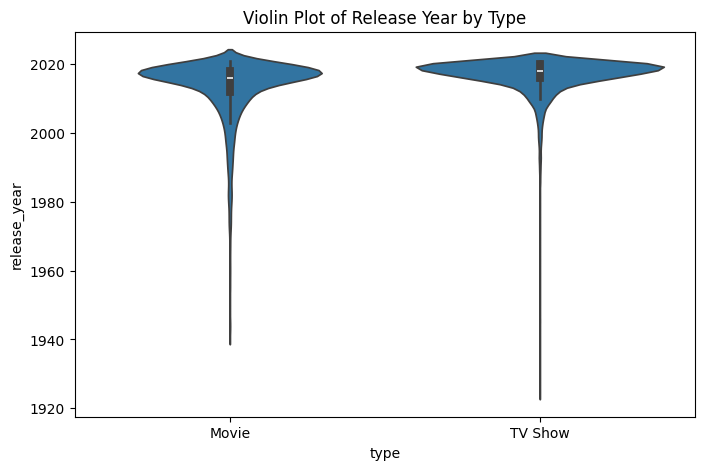

In [84]:
plt.figure(figsize=(8,5))
sns.violinplot(x="type", y="release_year", data=df)
plt.title("Violin Plot of Release Year by Type")
plt.show()

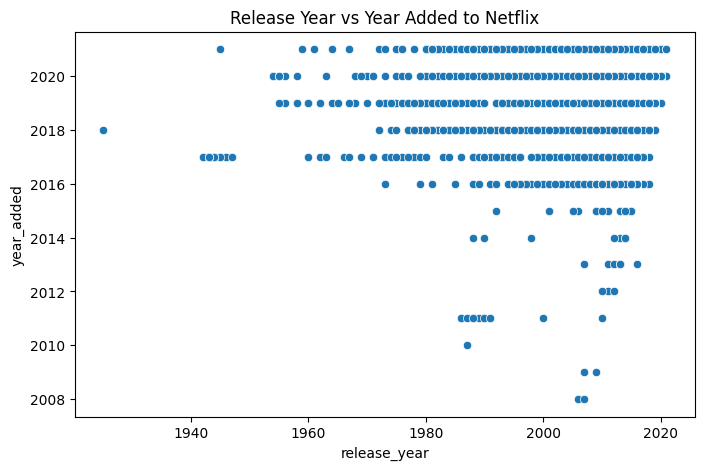

In [58]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="release_year", y="year_added")
plt.title("Release Year vs Year Added to Netflix")
plt.show()

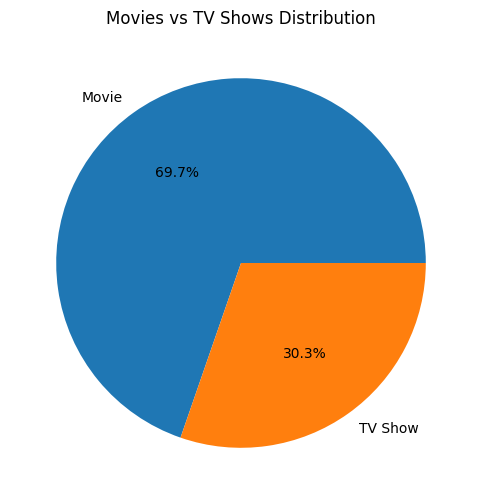

In [61]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Movies vs TV Shows Distribution")
plt.ylabel("")
plt.show()

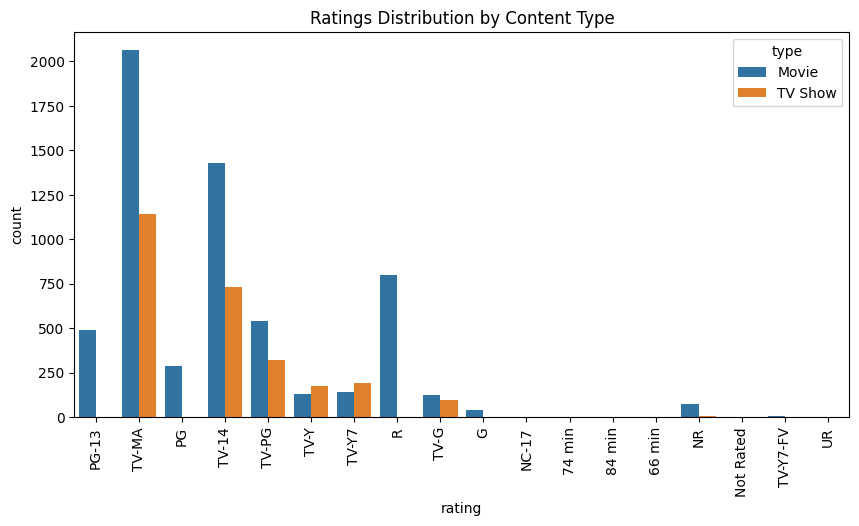

In [72]:
plt.figure(figsize=(10,5))
sns.countplot(x="rating", hue="type", data=df)
plt.xticks(rotation=90)
plt.title("Ratings Distribution by Content Type")
plt.show()

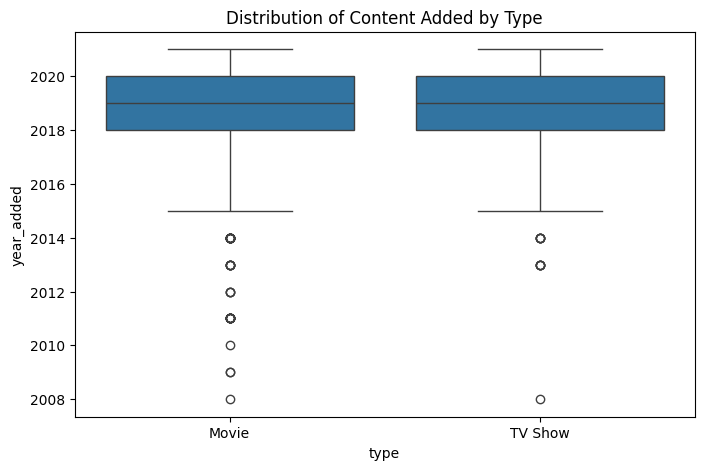

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(x="type", y="year_added", data=df)

plt.title("Distribution of Content Added by Type")
plt.show()

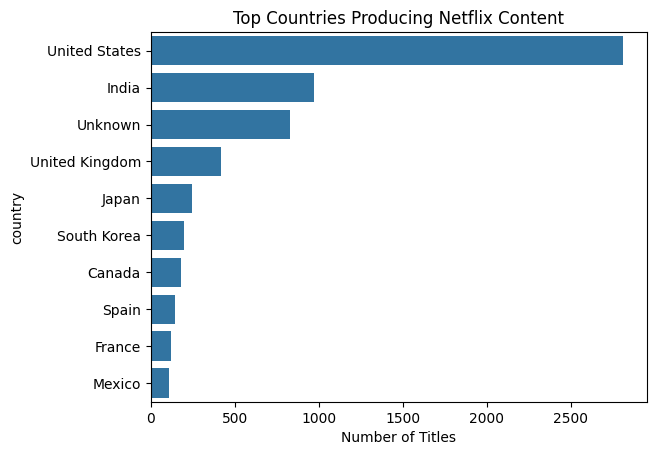

In [74]:
top_countries = df["country"].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.show()

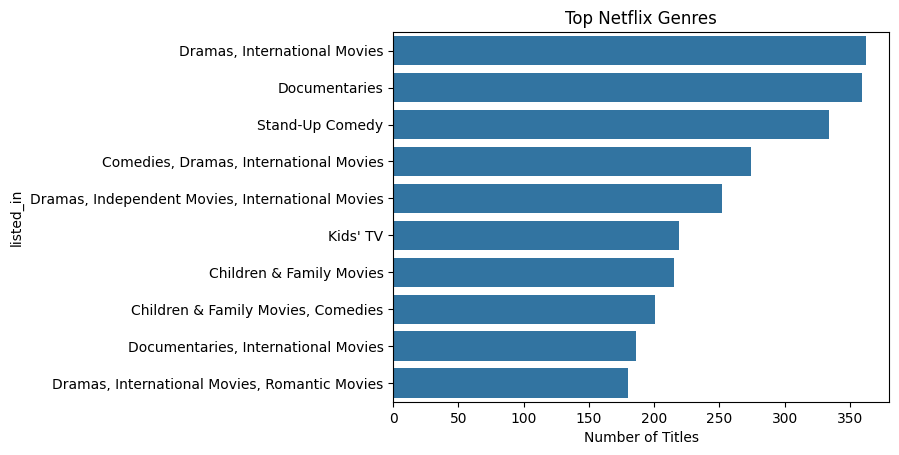

In [75]:
top_genres = df["listed_in"].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top Netflix Genres")
plt.xlabel("Number of Titles")
plt.show()

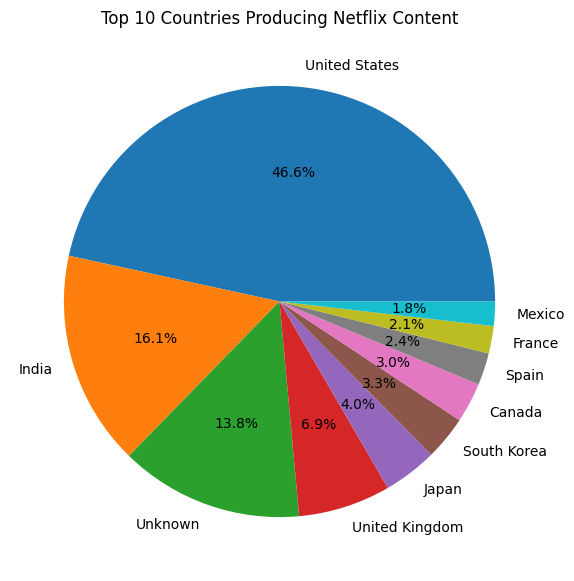

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

top_countries.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Top 10 Countries Producing Netflix Content")
plt.show()